In [ ]:
!nvidia-smi

Thu Apr 23 11:50:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics
!pip install roboflow

In [ ]:
# upload the data set of yout own face detectino in YOLOv8 format only
# Dataset that i used is from Roboflow and it is in YOLOv8 format
# link to the dataset: https://universe.roboflow.com/mohamed-traore-2ekkp/face-detection-mik1i/dataset/3
from google.colab import files
uploaded = files.upload()

In [ ]:
# for unzipping file if file in zip format
import zipfile
with zipfile.ZipFile('Face Detection.v2-augmented-images-v1.yolov8.zip','r') as zip_ref:
  zip_ref.extractall('/content/')

In [ ]:
# import model from ultralytics
import torch

from ultralytics import YOLO

model = YOLO('yolov8s.pt')

In [ ]:
# train model with our custom dataset whit additional parameters
result = model.train(
    data = '/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='face_detector',
    patience=10,
    device=0
)


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspe

In [ ]:
# evaluate our model and test on our test dataset
metrics = model.val()
print(f"MAP50 : {metrics.box.map50:.3f}")
print(f"Precision :{metrics.box.mp:.3f}")
print(f"Recall :{metrics.box.mr:.3f}")

test_results = model.predict(
    source='/content/test/images',
    conf=0.5,
    save=True,
    save_txt=True,
    save_conf=True,
    device=0
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 959.8±260.4 MB/s, size: 21.4 KB)
val: Scanning /content/valid/labels.cache... 173 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 66.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.8it/s 3.9s
                   all        173        442      0.837      0.787      0.846      0.487
Speed: 3.3ms preprocess, 10.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
MAP50 : 0.846
Precision :0.837
Recall :0.787

image 1/86 /content/test/images/-I1-MS09uaqsLdGTFkgnS0Rcg1mmPyAj95ySg_eckoM_jpeg_jpg.rf.294c47407587691ec56b9e0622295891.jpg: 640x640 2 faces, 16.1ms
image 2/86 /content/test/images/0ad90195-cd77-489e-bf85-08c83b80d3e0_jpg.rf.52a04224190f40

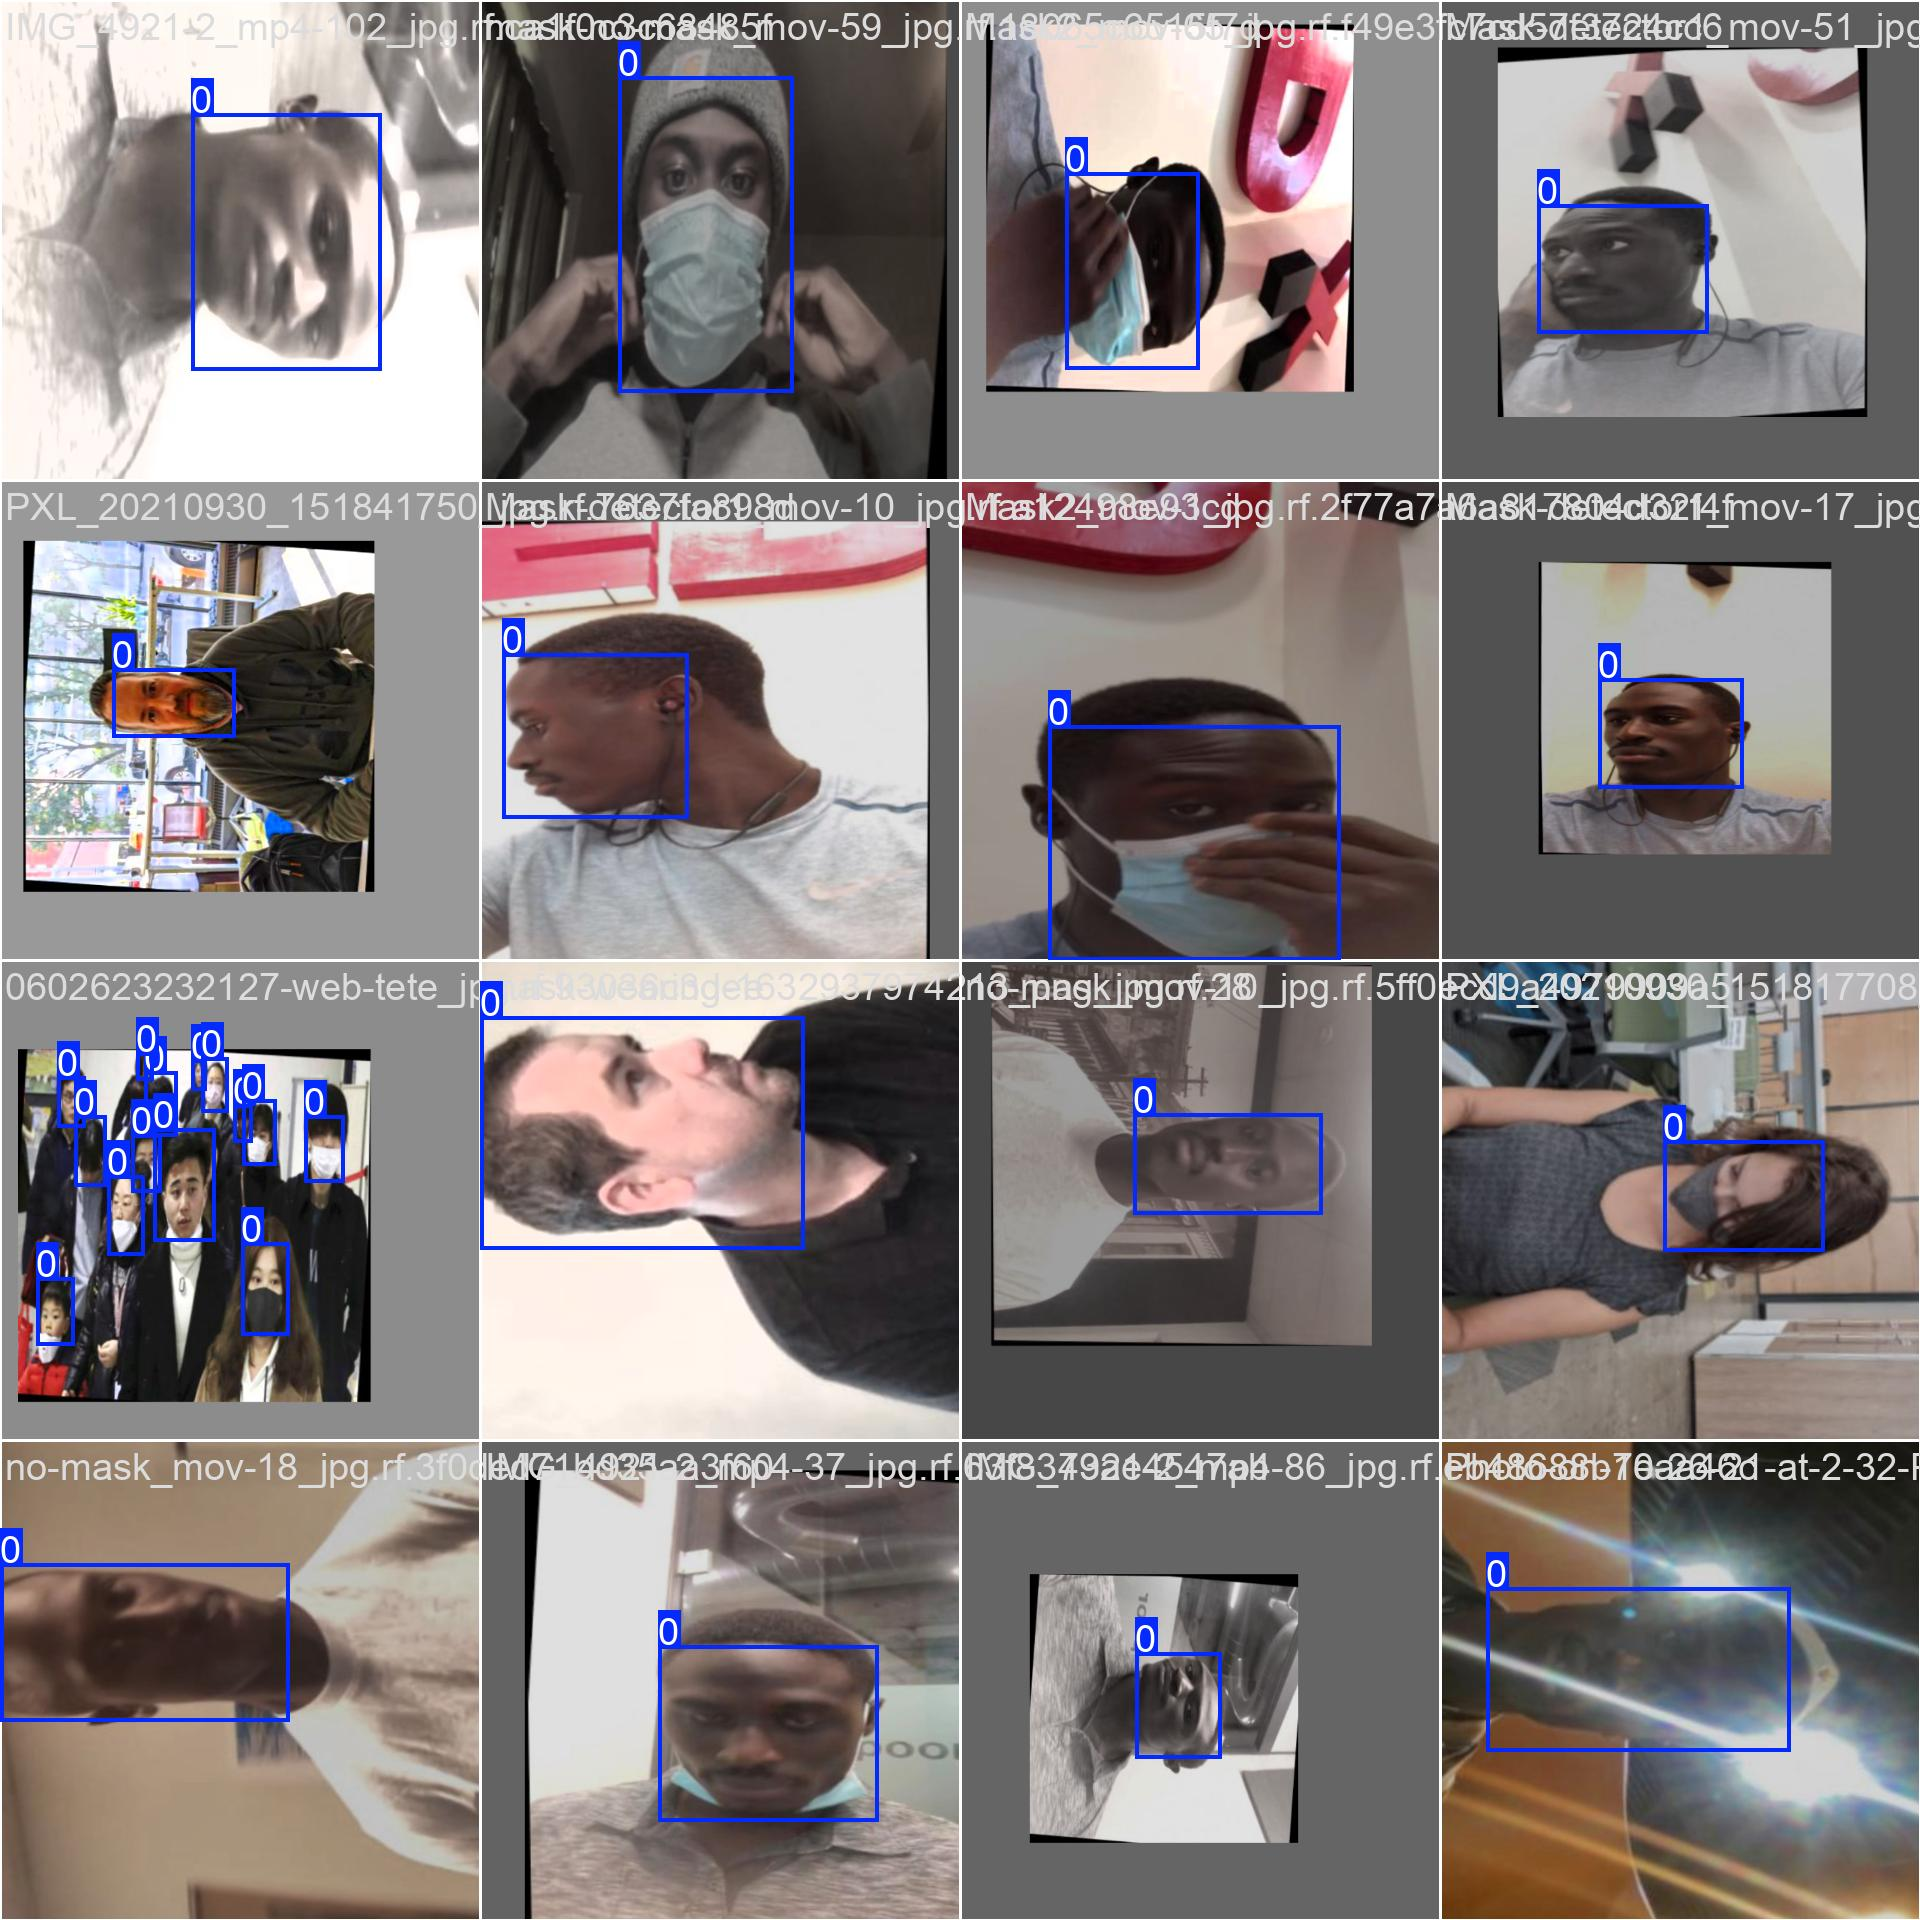

In [ ]:
# demo of our face detection model
from IPython.display import Image
import glob

pred_image = glob.glob('runs/detect/face_detector/*.jpg')
Image(pred_image[0])